<a href="https://colab.research.google.com/github/HowardHNguyen/Data_Science_for_Marketing_Solutions/blob/main/retail_reviewed_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Retail: assess causal feasibility and estimate price–sales associations


**Revision after inspecting the full workbook:** sections 1–3 retain the data audit. Section 4 tests a stricter sustained-price-change screen. Sections 5–6 provide a runnable fixed-effects **association** analysis when a causal event is not established. This is a different estimand from DiD, not a way of bypassing causal verification. No treatment or availability flags are set to True.


Question: Did a sustained price reduction change weekly gross units sold? Unit: product × week in one country. Proposed design: a common-date difference-in-differences (DiD), with product and week fixed effects and an event study. This is not a general staggered-adoption estimator.

Transaction prices can reflect bulk discounts, customer mix, clearance or demand responses. A price change found in transactions is a candidate for investigation, not evidence of exogenous treatment. The workbook contains purchases, not all offers or visits; it cannot estimate conversion rates.

# 1. Load from Drive and audit

Authorize the mount in Colab. The workbook is read without modification. Counts below refer to line items, not independent customers. No contents of the file are executed as instructions.

In [1]:
%pip -q install openpyxl statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')
online_retail = '/content/drive/MyDrive/data/online_retail_uci.xlsx'
data = pd.read_excel(online_retail, engine='openpyxl',
                     dtype={'InvoiceNo':'string', 'StockCode':'string', 'CustomerID':'string'})
print('Loaded:', data.shape)
display(data.head())

Mounted at /content/drive
Loaded: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  string        
 1   StockCode    541909 non-null  string        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  string        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2), string(3)
memory usage: 33.1+ MB


,0
Rows,541909
Exact repeated rows,5268
Cancellation rows,9288
Nonpositive quantity,10624
Nonpositive price,2517


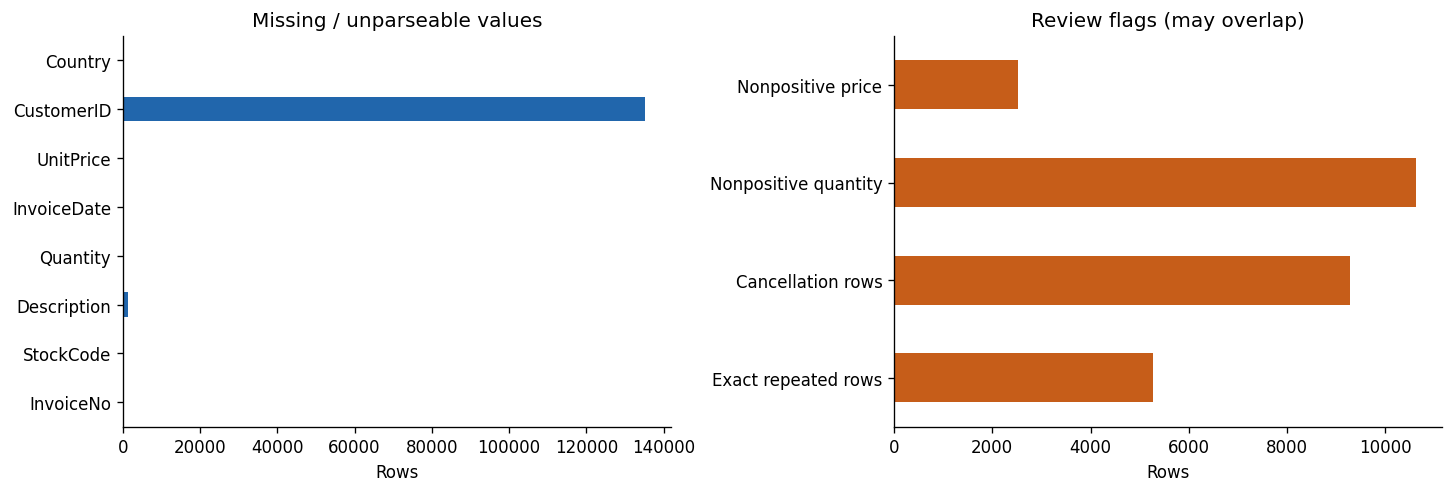

In [3]:
BLUE, ORANGE = '#2166ac', '#c65d19'
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
required=['InvoiceNo','StockCode','Description','Quantity','InvoiceDate','UnitPrice','CustomerID','Country']
assert set(required).issubset(data.columns), 'Unexpected workbook schema'
df=data[required].copy()
for c in ['InvoiceNo','StockCode','CustomerID']:
    df[c]=df[c].astype('string').str.strip()
# Excel datetime cells are handled directly. Text dates in the supplied example use month/day/year.
df['InvoiceDate']=pd.to_datetime(df.InvoiceDate, errors='coerce')
for c in ['Quantity','UnitPrice']: df[c]=pd.to_numeric(df[c], errors='coerce')
cancel=df.InvoiceNo.str.upper().str.startswith('C',na=False)
audit=pd.Series({'Rows':len(df),'Exact repeated rows':int(df.duplicated().sum()),
                 'Cancellation rows':int(cancel.sum()),'Nonpositive quantity':int(df.Quantity.le(0).sum()),
                 'Nonpositive price':int(df.UnitPrice.le(0).sum())})
display(audit)
fig, ax=plt.subplots(1,2,figsize=(12,4),layout='constrained')
df.isna().sum().plot.barh(ax=ax[0],color=BLUE,title='Missing / unparseable values')
audit.drop('Rows').plot.barh(ax=ax[1],color=ORANGE,title='Review flags (may overlap)')
ax[0].set_xlabel('Rows'); ax[1].set_xlabel('Rows'); plt.show()

flags overlap and should not be added together. Missing customer IDs do not automatically disqualify rows from a product-level analysis. Identical lines are retained unless provenance confirms accidental duplication.

# 2. Define merchandise sales and aggregate

Analyze UK gross positive merchandise purchases, not net sales after returns. Exclude cancellations, nonpositive quantities/prices, invalid essentials and service codes. Review codes for your file. The default merchandise pattern is a screening rule, not a verified product catalog. Zero transaction weeks remain unknown rather than automatically becoming zero demand.

,Excluded code rows
StockCode,
POST,1256
DOT,710
M,571
C2,144
D,77
S,63
BANK CHARGES,37
AMAZONFEE,34
CRUK,16


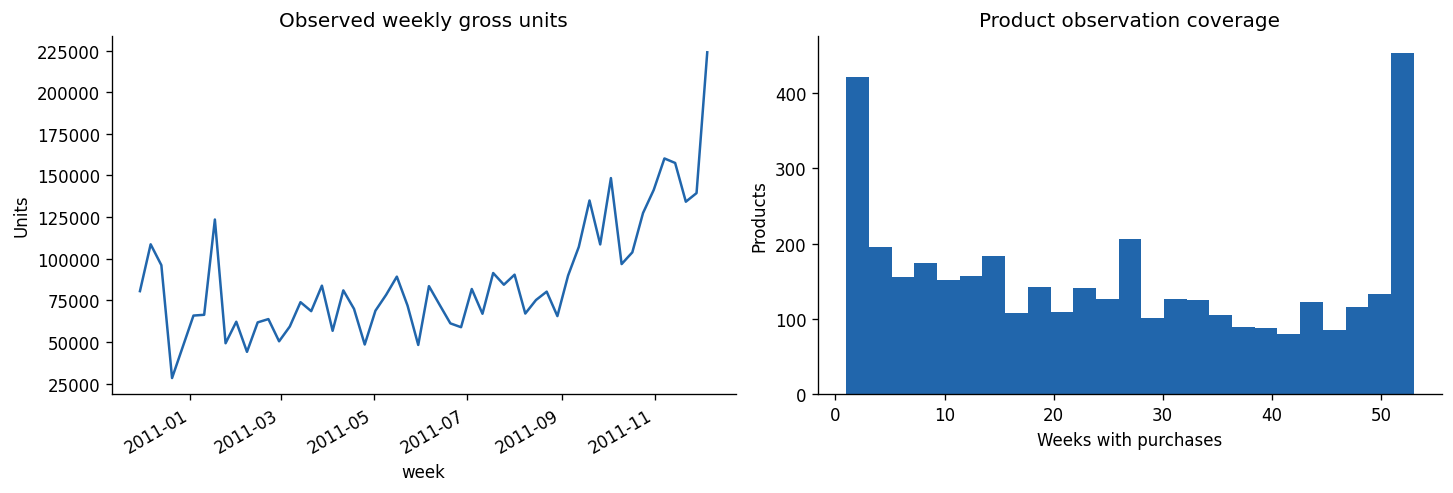

Eligible line items: 483971 Product-weeks with purchases: 98782


In [4]:
COUNTRY='United Kingdom'
SERVICE_CODES={'POST','D','M','DOT','C2','BANK CHARGES','AMAZONFEE','CRUK'}
merch=df.StockCode.str.fullmatch(r'\d{5}[A-Za-z]*',na=False) & ~df.StockCode.isin(SERVICE_CODES)
display(df.loc[~merch,'StockCode'].value_counts().head(20).rename('Excluded code rows'))
valid=(df.Country.eq(COUNTRY) & ~cancel & merch & df.Quantity.gt(0) & df.UnitPrice.gt(0)
       & df[['InvoiceNo','StockCode','InvoiceDate','Quantity','UnitPrice']].notna().all(axis=1)
       & np.isfinite(df.Quantity) & np.isfinite(df.UnitPrice))
sales=df.loc[valid].copy()
assert not sales.empty, 'No eligible merchandise records'
sales['week']=sales.InvoiceDate.dt.to_period('W-SUN').dt.start_time
weekly=sales.groupby(['StockCode','week'],observed=True).agg(
    units=('Quantity','sum'), price=('UnitPrice','median'),
    price_min=('UnitPrice','min'),price_max=('UnitPrice','max'), invoices=('InvoiceNo','nunique')).reset_index()
# Omit partial boundary weeks from causal analysis later.
timeline=weekly.groupby('week').units.sum()
fig, ax=plt.subplots(1,2,figsize=(12,4),layout='constrained')
timeline.plot(ax=ax[0],color=BLUE,title='Observed weekly gross units')
weekly.groupby('StockCode').week.nunique().plot.hist(bins=25,ax=ax[1],color=BLUE)
ax[0].set_ylabel('Units'); ax[1].set(title='Product observation coverage',xlabel='Weeks with purchases',ylabel='Products')
plt.show()
print('Eligible line items:',len(sales),'Product-weeks with purchases:',len(weekly))

seasonal changes and unequal product coverage complicate comparisons. A week without purchases does not tell us whether the item was in stock.

# 3. Inspect candidate price histories

The ranking below uses only transaction price changes, not estimated sales effects. Changes in the median can reflect purchaser composition. Review product descriptions, price dispersion, order sizes and business records before interpreting a candidate as a price policy.

,StockCode,week,previous_price,price,price_change,price_min,price_max
1506,16218,2011-06-06,2.080,0.06,-0.971154,0.06,0.06
76130,37340,2011-06-13,8.290,0.39,-0.952955,0.39,0.39
76128,37340,2011-05-30,8.290,0.39,-0.952955,0.39,0.39
76126,37340,2011-05-16,8.290,0.39,-0.952955,0.39,0.39
76882,40016,2011-03-21,8.290,0.42,-0.949337,0.42,8.29
94135,85175,2010-12-13,6.995,0.42,-0.939957,0.42,0.42
94140,85175,2011-01-31,6.855,0.42,-0.938731,0.42,13.29
94035,85172,2011-03-07,6.440,0.42,-0.934783,0.42,0.42
81316,79030D,2011-05-09,5.790,0.39,-0.932642,0.39,0.39
81319,79030D,2011-06-06,5.790,0.39,-0.932642,0.39,0.39


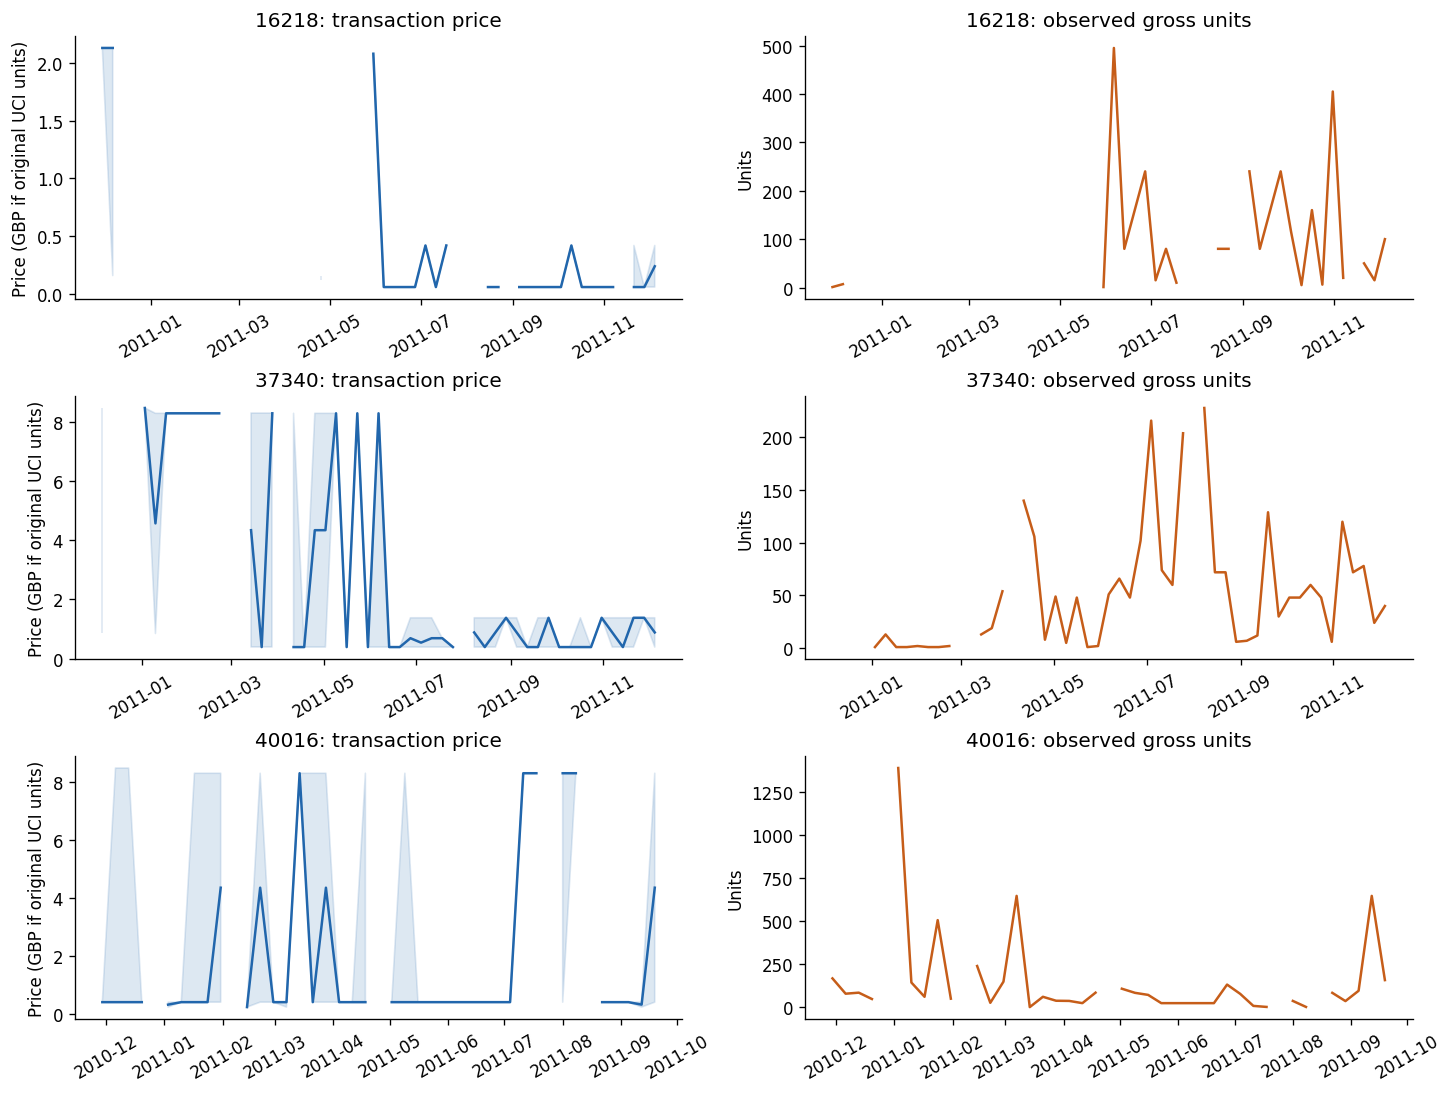

In [5]:
weekly=weekly.sort_values(['StockCode','week'])
weekly['previous_week']=weekly.groupby('StockCode').week.shift()
weekly['previous_price']=weekly.groupby('StockCode').price.shift()
weekly['price_change']=weekly.price/weekly.previous_price-1
consecutive=weekly.week.sub(weekly.previous_week).eq(pd.Timedelta(weeks=1))
candidates=weekly.loc[consecutive & weekly.price_change.le(-.10)].sort_values('price_change')
display(candidates[['StockCode','week','previous_price','price','price_change','price_min','price_max']].head(20))
PLOT_CODES=candidates.StockCode.drop_duplicates().head(3).tolist()
if not PLOT_CODES:
    PLOT_CODES=weekly.groupby('StockCode').week.nunique().nlargest(3).index.tolist()
fig, axes=plt.subplots(len(PLOT_CODES),2,figsize=(12,3*len(PLOT_CODES)),squeeze=False,layout='constrained')
for row, sku in enumerate(PLOT_CODES):
    z=weekly.loc[weekly.StockCode.eq(sku)].set_index('week').sort_index()
    # Reindex only for plotting gaps; do not fill missing values.
    z=z.reindex(pd.date_range(z.index.min(),z.index.max(),freq='W-MON'))
    axes[row,0].plot(z.index,z.price,color=BLUE)
    axes[row,0].fill_between(z.index,z.price_min,z.price_max,color=BLUE,alpha=.15)
    axes[row,0].set(title=f'{sku}: transaction price',ylabel='Price (GBP if original UCI units)')
    axes[row,1].plot(z.index,z.units,color=ORANGE)
    axes[row,1].set(title=f'{sku}: observed gross units',ylabel='Units')
    for ax in axes[row]: ax.tick_params(axis='x',rotation=30)
plt.show()

shaded price ranges show within-week dispersion. A clean, persistent change is more interpretable than mixed prices, but neither establishes causality. Do not select the event because its sales response looks favorable.

## 4. Screen for sustained price reductions

The original ranking selected the largest one-week drops. Here we instead require six observed weeks before and six after an event (omitting the event week), at least three invoices in every week, pre- and post-period weekly medians within 10% of their respective period medians, and a 10–50% price reduction. Controls must meet the same coverage/stability conditions and change by at most 3%.

These are analyst-chosen feasibility rules, not causal-identification tests. They were specified before computing this screen. Zero candidates means **no candidate under these rules**, not that no useful event exists anywhere. The screen can reject genuine events. Even a passing candidate requires substantive validation. We do not relax rules based on estimated effects.

,Product × candidate-date pairs
12 observed weeks,24477
Also ≥3 invoices/week,9393
Also stable before,5911
Also stable after,4666
Also 10–50% reduction,0


,StockCode,event,pre_price,post_price,price_change,potential_controls


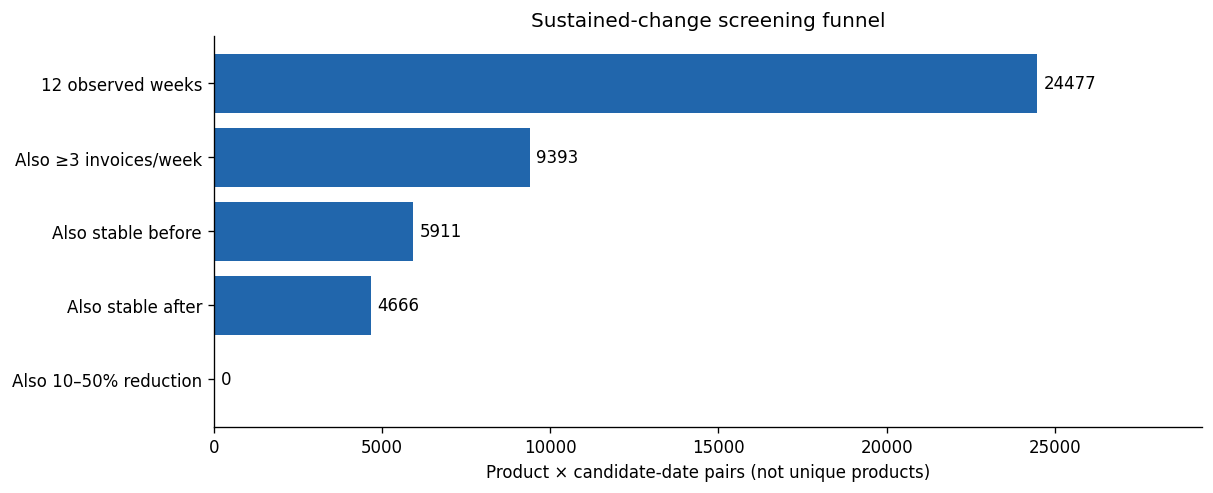

0 candidates passed. No candidate is automatically a verified intervention.


In [6]:
weeks=pd.date_range(weekly.week.min(),weekly.week.max(),freq='W-MON')
price_matrix=weekly.pivot(index='StockCode',columns='week',values='price').reindex(columns=weeks)
invoice_matrix=weekly.pivot(index='StockCode',columns='week',values='invoices').reindex(columns=weeks)
counts=np.zeros(5,dtype=int); screened=[]
for j in range(7,len(weeks)-7):
    pre=price_matrix.iloc[:,j-6:j]; post=price_matrix.iloc[:,j+1:j+7]
    a=pre.median(axis=1); b=post.median(axis=1)
    complete=pre.notna().all(axis=1)&post.notna().all(axis=1)
    enough=invoice_matrix.iloc[:,j-6:j].ge(3).all(axis=1)&invoice_matrix.iloc[:,j+1:j+7].ge(3).all(axis=1)
    sp=pre.div(a,axis=0).sub(1).abs().max(axis=1).le(.10)
    sq=post.div(b,axis=0).sub(1).abs().max(axis=1).le(.10)
    change=b/a-1
    stages=[complete,complete&enough,complete&enough&sp,complete&enough&sp&sq,complete&enough&sp&sq&change.between(-.50,-.10)]
    counts+=np.array([int(m.sum()) for m in stages])
    controls=complete&enough&sp&sq&change.abs().le(.03)
    for sku in price_matrix.index[stages[-1]]:
        screened.append({'StockCode':sku,'event':weeks[j], 'pre_price':a[sku], 'post_price':b[sku],
                         'price_change':change[sku],'potential_controls':int(controls.sum())})
screen=pd.DataFrame(screened,columns=['StockCode','event','pre_price','post_price','price_change','potential_controls'])
funnel=pd.Series(counts,index=['12 observed weeks','Also ≥3 invoices/week','Also stable before','Also stable after','Also 10–50% reduction'])
display(funnel.rename('Product × candidate-date pairs')); display(screen)
fig,ax=plt.subplots(figsize=(10,4),layout='constrained')
bars=ax.barh(funnel.index,funnel.values,color=BLUE)
ax.bar_label(bars,padding=4); ax.invert_yaxis(); ax.set_xlim(0,max(1,funnel.max())*1.2)
ax.set(title='Sustained-change screening funnel',xlabel='Product × candidate-date pairs (not unique products)')
plt.show()
print(f'{len(screen)} candidates passed. No candidate is automatically a verified intervention.')

**Read the chart:** it shows exactly where the candidate pool shrinks. The same product may appear at several candidate dates, so these counts are not independent observations.

## 5. A runnable exploratory model: within-product price–sales association

This section deliberately changes the question: **within consistently observed products, how do transaction prices and quantities move together, after removing product averages and common weekly changes?**

We regress log weekly units on log weekly median transaction price with product and week fixed effects. A balanced panel permits exact two-way demeaning. We retain products purchased in every included trading week. Entirely empty calendar weeks and partial boundary weeks are omitted and reported; no missing cell becomes a fabricated zero. Selection on continued purchases can introduce bias and limits the population represented.

The coefficient is a conditional log–log association. It is not identified demand elasticity: reverse causation, bulk discounts, customer mix, inventory and promotions remain possible explanations. Point estimates are descriptive; no causal confidence interval or significance claim is supplied.

Window: 2010-12-06 to 2011-11-28
Calendar weeks with no eligible purchases (excluded): ['2010-12-27']


,0
beta,-1.236386
products,251.000000
weeks,51.000000
observations,12801.000000


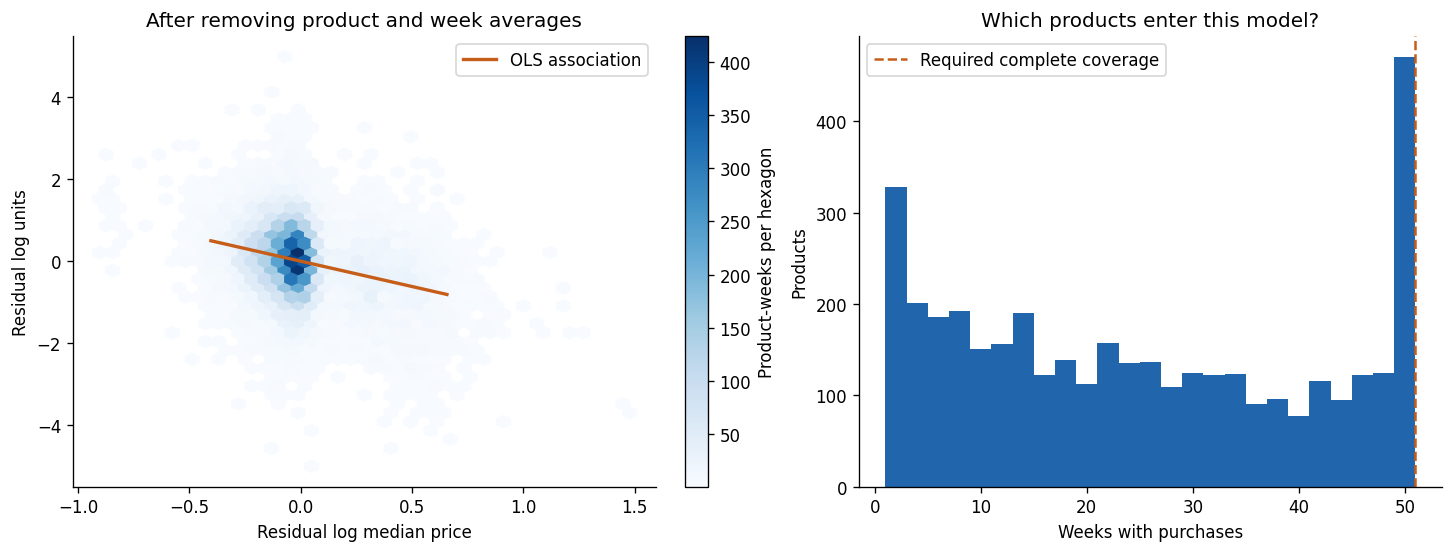

In [7]:
def fit_association(w, start, end):
    z=w.loc[w.week.between(pd.Timestamp(start),pd.Timestamp(end))].copy()
    P=z.pivot(index='StockCode',columns='week',values='price').sort_index(axis=1)
    Q=z.pivot(index='StockCode',columns='week',values='units').reindex(index=P.index,columns=P.columns)
    keep=P.notna().all(axis=1)&Q.notna().all(axis=1)&P.gt(0).all(axis=1)&Q.gt(0).all(axis=1)
    P=P.loc[keep]; Q=Q.loc[keep]
    assert len(P)>=2 and P.shape[1]>=4, 'Insufficient balanced panel'
    x=np.log(P.to_numpy(float)); y=np.log(Q.to_numpy(float))
    def demean(v): return v-v.mean(axis=1,keepdims=True)-v.mean(axis=0,keepdims=True)+v.mean()
    xr,yr=demean(x),demean(y)
    denominator=np.sum(xr*xr)
    assert denominator>1e-10, 'No identifying residual price variation'
    beta=float(np.sum(xr*yr)/denominator)
    assert np.isfinite(beta)
    return {'beta':beta,'products':len(P),'weeks':P.shape[1],'observations':P.size,'x':xr,'y':yr,'P':P}

# Full boundary weeks, derived from the actual data span.
first=sales.InvoiceDate.min().normalize()
last=sales.InvoiceDate.max().normalize()
available=sorted(weekly.week.unique())
full=[pd.Timestamp(t) for t in available if pd.Timestamp(t)>=first and pd.Timestamp(t)+pd.Timedelta(days=7)<=last]
assert len(full)>10
START,END=full[0],full[-1]
missing_calendar=pd.date_range(START,END,freq='W-MON').difference(pd.DatetimeIndex(full))
print('Window:',START.date(),'to',END.date())
print('Calendar weeks with no eligible purchases (excluded):',missing_calendar.strftime('%Y-%m-%d').tolist())
result=fit_association(weekly,START,END)
display(pd.Series({k:result[k] for k in ['beta','products','weeks','observations']}))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
hb=axes[0].hexbin(result['x'].ravel(),result['y'].ravel(),gridsize=40,mincnt=1,cmap='Blues')
lo,hi=np.quantile(result['x'],[.01,.99]); xx=np.linspace(lo,hi,100)
axes[0].plot(xx,result['beta']*xx,color=ORANGE,lw=2,label='OLS association')
axes[0].set(title='After removing product and week averages',xlabel='Residual log median price',ylabel='Residual log units')
axes[0].legend(); fig.colorbar(hb,ax=axes[0],label='Product-weeks per hexagon')
coverage=weekly.loc[weekly.week.between(START,END)].groupby('StockCode').week.nunique()
axes[1].hist(coverage,bins=25,color=BLUE)
axes[1].axvline(result['weeks'],color=ORANGE,ls='--',label='Required complete coverage')
axes[1].set(title='Which products enter this model?',xlabel='Weeks with purchases',ylabel='Products'); axes[1].legend()
plt.show()

**Read the charts:** the first displays residual association, not an intervention response. The second makes the sample restriction visible. A negative slope would not establish that reducing prices causes sales to rise.

## 6. Descriptive sensitivity and reporting

Compare the full window, the first and second halves of the observed window, and removal of identical transaction lines. Window analyses reselect eligible products, so differences combine changes in period and sample composition. Duplicate removal is a sensitivity analysis because identical records are not necessarily erroneous. These are checks of association stability, not causal robustness tests.

,specification,beta,products,weeks,observations
0,Full window,-1.236386,251,51,12801
1,First half,-1.396451,364,25,9100
2,Second half,-1.377478,528,26,13728
3,Remove identical lines,-1.226093,251,51,12801


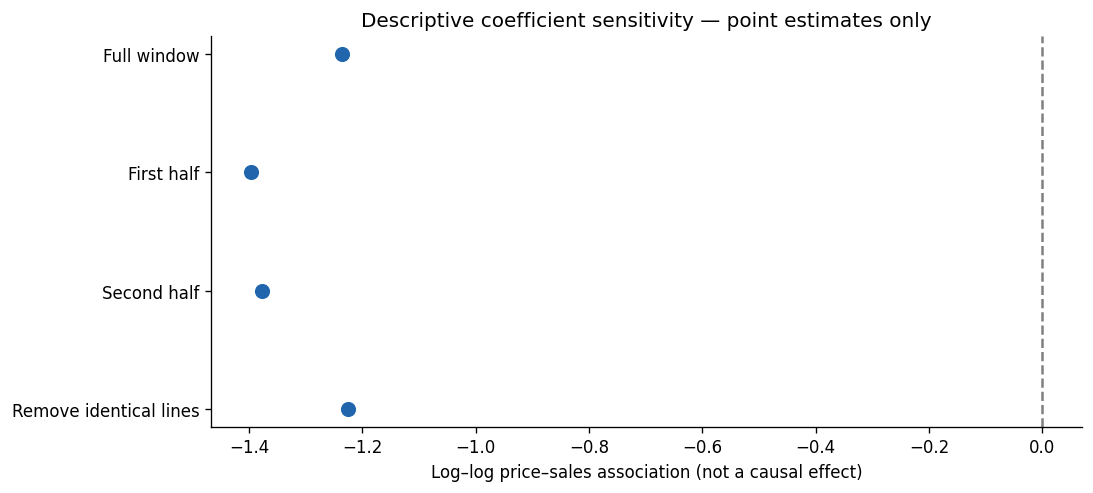

Report: This observational fixed-effects model estimates an association among consistently observed products.
It does not identify the causal effect of a price reduction. No DiD treatment event has been verified.


In [8]:
mid=full[len(full)//2]
specs=[('Full window',weekly,START,END),('First half',weekly,START,mid-pd.Timedelta(weeks=1)),('Second half',weekly,mid,END)]
dedup=sales.drop_duplicates(subset=required)
wd=dedup.groupby(['StockCode','week']).agg(units=('Quantity','sum'),price=('UnitPrice','median')).reset_index()
specs.append(('Remove identical lines',wd,START,END))
rows=[]
for name,w,begin,finish in specs:
    r=fit_association(w,begin,finish)
    rows.append({'specification':name,**{k:r[k] for k in ['beta','products','weeks','observations']}})
association_results=pd.DataFrame(rows)
display(association_results)
fig,ax=plt.subplots(figsize=(9,4),layout='constrained')
ax.scatter(association_results.beta,association_results.specification,color=BLUE,s=65)
ax.axvline(0,color='gray',ls='--'); ax.invert_yaxis()
ax.set(title='Descriptive coefficient sensitivity — point estimates only',xlabel='Log–log price–sales association (not a causal effect)')
plt.show()
screen.to_csv('retail_sustained_price_candidates.csv',index=False)
association_results.to_csv('retail_association_results.csv',index=False)
print('Report: This observational fixed-effects model estimates an association among consistently observed products.')
print('It does not identify the causal effect of a price reduction. No DiD treatment event has been verified.')

# Conclusion

The analysis found a negative association between transaction prices and weekly units sold after controlling for product and week fixed effects. However, a verified pricing intervention was not established, and potential confounding and reverse causality remain. Consequently, the results should not be interpreted as a causal demand elasticity or used alone to recommend price reductions.

## What would permit a causal follow-up?
A documented price policy or randomized pricing experiment, known treatment assignment dates, offered-price and availability histories, and defensible comparisons could support an intervention analysis. A passing screen alone is insufficient. This notebook does not estimate individual purchase conversion or effects on products with no observed sales.

Source: the user-linked `online_retail_uci.xlsx`, accessed and screened locally; 541,909 rows and 8 columns. The workbook was not modified. The saved code retains the user's Google Drive path for Colab reruns.